In [1]:
#XG Boost example 

In [2]:
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [3]:
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3*X[:, 0]**2 + 0.05 * np.random.randn(100)

In [4]:
df = pd.DataFrame()
df['X'] = X.reshape(100)
df['y'] = y

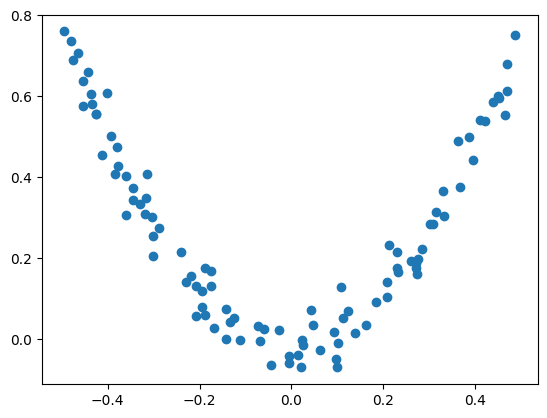

In [5]:
plt.scatter(df['X'], df['y'])

In [6]:
df

,X,y
0,-0.125460,0.051573
1,0.450714,0.594480
2,0.231994,0.166052
3,0.098658,-0.070178
4,-0.343981,0.343986
...,...,...
95,-0.006204,-0.040675
96,0.022733,-0.002305
97,-0.072459,0.032809
98,-0.474581,0.689516


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       100 non-null    float64
 1   y       100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


In [8]:
X_train, X_test, y_train, y_test = train_test_split(df['X'], df['y'], test_size=0.2)

# converting dataset into dmetrix # this is only for classification 
xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_test = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [10]:
xgb_r = xgb.XGBRegressor(objective ='reg:linear',n_estimators = 10, seed = 123)

In [12]:
xgb_r.fit(X_train, y_train)

/home/master/python/MachineLeaning/venv3/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [17:26:51] WARNING: /workspace/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=10,
             n_jobs=None, num_parallel_tree=None, ...)

In [19]:
from sklearn.metrics import r2_score
preds = xgb_r.predict(X_test)
preds
r2_score(y_test, preds)
# accuracy= accuracy_score(y_test,preds)
# print('Accuracy of the model is:', accuracy*100)

0.8978611526494976

In [ ]:
pip uninstall  xgboost -y